# Notebook 05 — Country Profile Calibration

This notebook:
1. **Fixes critical inflation data contamination** discovered after Notebook 04
2. Completes climate risk tier assignments
3. Recomputes calibration profiles for the 3x3 experimental matrix
4. Estimates transition dynamics (debt accumulation, growth, climate-fiscal)
5. Characterises shock processes for the Gymnasium environment
6. Validates calibration against known historical episodes
7. Produces 4 publication-quality figures

**Inputs**: `data/processed/master_panel_engineered.csv`  
**Outputs**: 7 data files + 8 figure files (PNG + SVG each)

In [3]:
import os, json, warnings
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

matplotlib.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'font.family': 'sans-serif',
})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)
CB_COLORS = ['#0072B2','#E69F00','#009E73','#CC79A7','#56B4E9','#D55E00','#F0E442','#000000']
print('Setup complete.')

Working directory: c:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent
Setup complete.


In [4]:
df = pd.read_csv('data/processed/master_panel_engineered.csv')
df = df.sort_values(['iso3','year']).reset_index(drop=True)
print(f'Loaded master_panel_engineered: {df.shape}')
with open('data/processed/scaling_parameters.json') as f:
    scaling_params = json.load(f)
print(f'Interest rate source from Notebook 04: {scaling_params["interest_rate_source"]}')

Loaded master_panel_engineered: (7559, 88)
Interest rate source from Notebook 04: real_interest_rate_winsorised


---
### Step 0: Fix Inflation and Interest Rate Contamination

#### The Problem

`weo_inflation_cpi` contains **CPI index levels** (cumulative price levels relative to a base year), NOT annual inflation rates. E.g. USA 2020: `weo_inflation_cpi = 258.846` (actual 2020 inflation ~1.2%). Brazil values are in the trillions from compounded hyperinflation.

This contaminated `inflation`, `real_interest_rate` (= implicit_rate - inflation, giving -53 trillion for Brazil), `r_minus_g`, and the normalised state variables `state_interest_rate` and `state_risk_premium`.

The `implicit_interest_rate` is clean (0-100%, median ~3.2%). `wdi_inflation_cpi` correctly contains annual rates.

#### The Solution
Convert the WEO CPI index to annual rates using `pct_change()`, then rebuild all downstream variables.

In [5]:
# Step 0a: Convert WEO CPI index to annual inflation rates
print('=== STEP 0a: Convert WEO CPI index to annual inflation rates ===')

df['inflation_UNCORRECTED']          = df['inflation'].copy()
df['real_interest_rate_UNCORRECTED'] = df['real_interest_rate'].copy()
df['r_minus_g_UNCORRECTED']          = df['r_minus_g'].copy()

df['weo_inflation_rate'] = df.groupby('iso3')['weo_inflation_cpi'].pct_change() * 100

print('Verification checks (expected within +/-1.5 pp):')
checks = [('USA',2021,4.7), ('USA',2022,8.0), ('BRA',2022,9.3)]
all_ok = True
for iso, yr, expected in checks:
    row = df[(df['iso3']==iso) & (df['year']==yr)]
    if len(row)==0:
        print(f'  {iso} {yr}: NOT FOUND'); all_ok=False; continue
    val = row['weo_inflation_rate'].values[0]
    ok = abs(val-expected)<=1.5
    print(f'  {iso} {yr}: computed={val:.2f}%, expected~{expected}% [{"OK" if ok else "FLAG"}]')
    if not ok: all_ok=False
print()
print('All verification checks passed.' if all_ok else 'WARNING: Some checks outside tolerance.')
print(f'\nweo_inflation_rate non-null: {df["weo_inflation_rate"].notna().sum():,}')
print(df['weo_inflation_rate'].describe(percentiles=[0.01,0.25,0.5,0.75,0.99]))

=== STEP 0a: Convert WEO CPI index to annual inflation rates ===
Verification checks (expected within +/-1.5 pp):
  USA 2021: computed=4.68%, expected~4.7% [OK]
  USA 2022: computed=7.99%, expected~8.0% [OK]
  BRA 2022: computed=9.28%, expected~9.3% [OK]

All verification checks passed.

weo_inflation_rate non-null: 7,274
count    7274.0000
mean       29.0909
std       814.6389
min       -99.9999
1%         -2.5208
25%         1.9815
50%         3.7590
75%         7.9343
99%       199.3216
max     65374.1075
Name: weo_inflation_rate, dtype: float64


In [6]:
# Step 0b: Corrected consolidated inflation
print('=== STEP 0b: Corrected consolidated inflation ===')

df['inflation_corrected'] = df['weo_inflation_rate'].combine_first(df['wdi_inflation_cpi'])

n_weo = df['weo_inflation_rate'].notna().sum()
n_wdi = (df['weo_inflation_rate'].isna() & df['wdi_inflation_cpi'].notna()).sum()
print(f'From WEO pct_change: {n_weo:,}')
print(f'From WDI (fallback): {n_wdi:,}')
print(f'Total non-null:      {df["inflation_corrected"].notna().sum():,}')
print(df['inflation_corrected'].describe(percentiles=[0.01,0.25,0.5,0.75,0.99]))

=== STEP 0b: Corrected consolidated inflation ===
From WEO pct_change: 7,274
From WDI (fallback): 186
Total non-null:      7,460
count    7460.0000
mean       30.9429
std       810.1610
min       -99.9999
1%         -2.5212
25%         1.9947
50%         3.8310
75%         8.0711
99%       227.5623
max     65374.1075
Name: inflation_corrected, dtype: float64


In [7]:
# Step 0c: Recompute real interest rate
print('=== STEP 0c: Corrected real interest rate ===')

df['real_interest_rate_corrected'] = df['implicit_interest_rate'] - df['inflation_corrected']

print('Distribution (before winsorisation):')
print(df['real_interest_rate_corrected'].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))

extremes = df[df['real_interest_rate_corrected'].abs()>50][
    ['iso3','year','real_interest_rate_corrected','inflation_corrected','implicit_interest_rate']]
print(f'\nExtreme values (|real_rate|>50): {len(extremes)}')
if len(extremes)>0:
    print(extremes.sort_values('real_interest_rate_corrected').head(20).to_string(index=False))
    print('Note: genuine hyperinflationary episodes, not data errors.')

=== STEP 0c: Corrected real interest rate ===
Distribution (before winsorisation):
count     4848.0000
mean       -14.9090
std        983.9805
min     -65374.1075
1%         -79.7007
5%         -18.5317
25%         -3.1443
50%          0.0528
75%          5.8705
95%         60.2942
99%         84.5189
max         97.4562
Name: real_interest_rate_corrected, dtype: float64

Extreme values (|real_rate|>50): 428
iso3  year  real_interest_rate_corrected  inflation_corrected  implicit_interest_rate
 VEN  2018                   -65374.1075           65374.1075                 -0.0000
 VEN  2019                   -19906.0094           19906.0240                  0.0146
 AGO  1996                    -2599.8989            2600.0000                  0.1011
 VEN  2020                    -2354.6338            2355.1472                  0.5134
 AZE  1994                    -1663.9069            1663.9069                 -0.0000
 VEN  2021                    -1588.0000            1588.5131           

In [8]:
# Step 0d: Winsorise real interest rate
print('=== STEP 0d: Winsorisation (1st/99th percentile) ===')


p01 = df['real_interest_rate_corrected'].quantile(0.01)
p99 = df['real_interest_rate_corrected'].quantile(0.99)
print(f'Lower clip: {p01:.2f}%  |  Upper clip: {p99:.2f}%')
n_lo = (df['real_interest_rate_corrected']<p01).sum()
n_hi = (df['real_interest_rate_corrected']>p99).sum()
print(f'Clipped low: {n_lo}  |  Clipped high: {n_hi}')

df['real_interest_rate_winsorised'] = df['real_interest_rate_corrected'].clip(p01, p99)
print(df['real_interest_rate_winsorised'].describe())

=== STEP 0d: Winsorisation (1st/99th percentile) ===
Lower clip: -79.70%  |  Upper clip: 84.52%
Clipped low: 49  |  Clipped high: 49
count   4848.0000
mean       5.6918
std       24.0459
min      -79.7007
25%       -3.1443
50%        0.0528
75%        5.8705
max       84.5189
Name: real_interest_rate_winsorised, dtype: float64


In [9]:
# Step 0e: Recompute r - g
print('=== STEP 0e: Corrected r - g differential ===')

df['r_minus_g_corrected'] = df['real_interest_rate_winsorised'] - df['gdp_growth']
print(df['r_minus_g_corrected'].describe())

print('\nMedian r-g by economy type (historical, non-projection):')
for etype in ['Advanced','Emerging Market','Developing']:
    sub = df[(df['economy_type']==etype) & df['r_minus_g_corrected'].notna() & ~df['is_projection']]
    print(f'  {etype}: median={sub["r_minus_g_corrected"].median():.2f}%  n={len(sub):,}')

print('\n--- Sanity check: USA, BRA, KEN, JPN (2015-2023) ---')
s = df[df['iso3'].isin(['USA','BRA','KEN','JPN'])][['iso3','year',
    'real_interest_rate_winsorised','gdp_growth','r_minus_g_corrected']].query('year>=2015 and year<=2023')
print(s.to_string(index=False))

=== STEP 0e: Corrected r - g differential ===
count   4848.0000
mean       3.8346
std       64.5196
min     -779.7007
25%       -7.8777
50%       -2.8868
75%        5.0327
max     3275.7202
Name: r_minus_g_corrected, dtype: float64

Median r-g by economy type (historical, non-projection):
  Advanced: median=1.32%  n=1,444
  Emerging Market: median=-4.10%  n=1,015
  Developing: median=-5.05%  n=1,528

--- Sanity check: USA, BRA, KEN, JPN (2015-2023) ---
iso3  year  real_interest_rate_winsorised  gdp_growth  r_minus_g_corrected
 BRA  2015                            NaN     -3.5456                  NaN
 BRA  2016                            NaN     -3.2760                  NaN
 BRA  2017                            NaN      1.3229                  NaN
 BRA  2018                            NaN      1.7839                  NaN
 BRA  2019                            NaN      1.2205                  NaN
 BRA  2020                            NaN     -3.2761                  NaN
 BRA  2021        

In [10]:
# Step 0f: Recompute normalised state_interest_rate and state_risk_premium
print('=== STEP 0f: Recompute normalised state variables ===')

hist_mask = ~df['is_projection']
economy_types = ['Advanced','Emerging Market','Developing']

recompute_map = {
    'state_interest_rate': 'real_interest_rate_winsorised',
    'state_risk_premium':  'r_minus_g_corrected',
}

for state_col, source_col in recompute_map.items():
    scaling_params['parameters'][state_col] = {}
    scale_lookup = {}
    for etype in economy_types:
        mask = hist_mask & (df['economy_type']==etype) & df[source_col].notna()
        vals = df.loc[mask, source_col]
        if len(vals)<10:
            vals = df.loc[hist_mask & df[source_col].notna(), source_col]
        q25,q75 = vals.quantile(0.25), vals.quantile(0.75)
        iqr = q75-q25
        if iqr==0: iqr = vals.std()
        median = vals.median()
        scaling_params['parameters'][state_col][etype] = {'median':float(median),'iqr':float(iqr)}
        scale_lookup[etype] = (median,iqr)
    medians = df['economy_type'].map({et:scale_lookup[et][0] for et in economy_types})
    iqrs    = df['economy_type'].map({et:scale_lookup[et][1] for et in economy_types})
    df[state_col] = (df[source_col]-medians)/iqrs
    print(f'{state_col}: mean={df[state_col].mean():.3f} std={df[state_col].std():.3f} non-null={df[state_col].notna().sum():,}')

scaling_params['state_variable_map']['state_interest_rate'] = 'real_interest_rate_winsorised'
scaling_params['state_variable_map']['state_risk_premium']  = 'r_minus_g_corrected'
scaling_params['interest_rate_source'] = 'real_interest_rate_winsorised'
print('Scaling parameters updated.')

=== STEP 0f: Recompute normalised state variables ===
state_interest_rate: mean=0.330 std=1.929 non-null=4,848
state_risk_premium: mean=0.356 std=4.718 non-null=4,848
Scaling parameters updated.


In [11]:
# Step 0g: Save corrected outputs
print('=== STEP 0g: Save corrected outputs ===')

print(f'Before/after (median real_interest_rate):')
print(f'  UNCORRECTED: {df["real_interest_rate_UNCORRECTED"].median():.4f}')
print(f'  CORRECTED:   {df["real_interest_rate_winsorised"].median():.4f}')
print(f'Before/after (median r_minus_g):')
print(f'  UNCORRECTED: {df["r_minus_g_UNCORRECTED"].median():.4f}')
print(f'  CORRECTED:   {df["r_minus_g_corrected"].median():.4f}')

df['inflation']          = df['inflation_corrected']
df['real_interest_rate'] = df['real_interest_rate_winsorised']
df['r_minus_g']          = df['r_minus_g_corrected']

df.to_csv('data/processed/master_panel_engineered.csv', index=False)
print(f'\nmaster_panel_engineered.csv saved: {df.shape}')

with open('data/processed/scaling_parameters.json','w') as f:
    json.dump(scaling_params, f, indent=2)
print('scaling_parameters.json updated.')

=== STEP 0g: Save corrected outputs ===
Before/after (median real_interest_rate):
  UNCORRECTED: 0.0528
  CORRECTED:   0.0528
Before/after (median r_minus_g):
  UNCORRECTED: -2.8868
  CORRECTED:   -2.8868

master_panel_engineered.csv saved: (7559, 88)
scaling_parameters.json updated.


---
## Step 1: Assign Climate Risk Tiers to Unclassified Countries

11 countries have no `climate_risk_tier`. We handle them in two ways:

1. **KNA** (St. Kitts and Nevis, INFORM vulnerability=1.2) -> **Low**
2. **SSD** (South Sudan, INFORM vulnerability=9.0) -> **High**
3. **9 territories** (ABW, AND, HKG, MAC, PRI, SMR, TWN, UVK, WBG) excluded from `rl_training_data.csv`.

**DISSERTATION NOTE**: Document exclusion of 9 territories in methodology. They are microstates/territories not covered by standard international databases, <0.5% of dataset.

In [12]:
# Step 1: Assign tiers and exclude territories
print('=== STEP 1: Climate risk tier assignment ===')

df.loc[df['iso3']=='KNA','climate_risk_tier'] = 'Low'
df.loc[df['iso3']=='SSD','climate_risk_tier'] = 'High'
print('  KNA (St. Kitts and Nevis): INFORM vulnerability=1.2 -> Low')
print('  SSD (South Sudan): INFORM vulnerability=9.0 -> High')

EXCLUDE_FROM_RL = ['ABW','AND','HKG','MAC','PRI','SMR','TWN','UVK','WBG']
print(f'\nExcluding {len(EXCLUDE_FROM_RL)} territories from RL training data:')
for iso in EXCLUDE_FROM_RL:
    rows = df[df['iso3']==iso]
    name = rows['country_name'].iloc[0] if len(rows)>0 else 'N/A'
    print(f'  {iso} ({name}): {len(rows)} rows')

n_excl = df[df['iso3'].isin(EXCLUDE_FROM_RL)].shape[0]
print(f'Total rows excluded: {n_excl}')

remaining_nan = df[~df['iso3'].isin(EXCLUDE_FROM_RL) & df['climate_risk_tier'].isna()]
print(f'Remaining NaN climate_risk_tier (excl. excluded): {len(remaining_nan)}')

print('\n=== Updated 3x3 Matrix (non-excluded countries) ===')
rl_meta = df[~df['iso3'].isin(EXCLUDE_FROM_RL)][['iso3','economy_type','climate_risk_tier']].drop_duplicates('iso3')
xtab = pd.crosstab(rl_meta['economy_type'], rl_meta['climate_risk_tier'], margins=True, margins_name='Total')
col_order = [c for c in ['Low','Medium','High','Total'] if c in xtab.columns]
row_order = [r for r in ['Advanced','Emerging Market','Developing','Total'] if r in xtab.index]
print(xtab.loc[row_order,col_order].to_string())

=== STEP 1: Climate risk tier assignment ===
  KNA (St. Kitts and Nevis): INFORM vulnerability=1.2 -> Low
  SSD (South Sudan): INFORM vulnerability=9.0 -> High

Excluding 9 territories from RL training data:
  ABW (Aruba): 40 rows
  AND (Andorra): 30 rows
  HKG (Hong Kong SAR, China): 40 rows
  MAC (Macao SAR, China): 34 rows
  PRI (Puerto Rico (U.S.)): 40 rows
  SMR (San Marino): 33 rows
  TWN (Taiwan, China): 40 rows
  UVK (nan): 30 rows
  WBG (nan): 31 rows
Total rows excluded: 318
Remaining NaN climate_risk_tier (excl. excluded): 0

=== Updated 3x3 Matrix (non-excluded countries) ===
climate_risk_tier  Low  Medium  High  Total
economy_type                               
Advanced            44      14     2     60
Emerging Market     14      34     5     53
Developing           5      13    56     74
Total               63      61    63    187


---
## Step 2: Recompute Calibration Profiles

With corrected interest rates and complete tier assignments, we recompute the 9-profile calibration table. These profiles are the *starting state distributions* for the Gymnasium environment.

Using only **2000-2024 historical data** (excluding projections) for reliable coverage.

In [13]:
# Step 2: Recompute calibration profiles
print('=== STEP 2: Calibration profiles (corrected) ===')

calib_df = df[
    (df['year']>=2000) & (df['year']<=2024) &
    ~df['is_projection'] & ~df['iso3'].isin(EXCLUDE_FROM_RL)
].copy()
print(f'Calibration dataset: {calib_df.shape}')

state_src = {
    'output_growth':      'gdp_growth',
    'debt_to_gdp':        'debt_to_gdp',
    'primary_balance':    'weo_primary_balance',
    'interest_rate':      'real_interest_rate_winsorised',
    'climate_shock':      'climate_damage_gdp_pct_5yr',
    'adaptation_capital': 'ndgain_readiness',
    'risk_premium':       'r_minus_g_corrected',
}

rows, sparse_cells = [], []

for etype in ['Advanced','Emerging Market','Developing']:
    for tier in ['Low','Medium','High']:
        mask = (calib_df['economy_type']==etype) & (calib_df['climate_risk_tier']==tier)
        sub = calib_df[mask]
        n_ctry, n_obs = sub['iso3'].nunique(), len(sub)
        row = {'economy_type':etype,'climate_risk_tier':tier,'n_countries':n_ctry,'n_observations':n_obs}
        for sv,src in state_src.items():
            vals = sub[src].dropna()
            if len(vals)>=3:
                row.update({f'{sv}_median':vals.median(),f'{sv}_mean':vals.mean(),
                            f'{sv}_std':vals.std(),f'{sv}_p25':vals.quantile(0.25),
                            f'{sv}_p75':vals.quantile(0.75),f'{sv}_min':vals.min(),f'{sv}_max':vals.max()})
            else:
                for sfx in ['median','mean','std','p25','p75','min','max']: row[f'{sv}_{sfx}']=np.nan
        if n_ctry<5 or n_obs<100: sparse_cells.append((etype,tier,n_ctry,n_obs))
        rows.append(row)

calib_v2 = pd.DataFrame(rows)
pd.set_option('display.float_format','{:.3f}'.format)
mc = ['economy_type','climate_risk_tier','n_countries','n_observations']+[f'{s}_median' for s in state_src]
print('\nCalibration profiles (medians):')
print(calib_v2[mc].to_string(index=False))

print('\nSPARSE CELLS (flag for methodology):')
for etype,tier,n_ctry,n_obs in sparse_cells:
    ctry_list = list(calib_df[(calib_df['economy_type']==etype)&(calib_df['climate_risk_tier']==tier)]['iso3'].unique())
    print(f'  {etype} x {tier}: {n_ctry} countries, {n_obs} obs -> {ctry_list}')
    print(f'    DISSERTATION NOTE: RL agents on this cell should be interpreted with caution.')

calib_v2.to_csv('data/processed/calibration_profiles_v2.csv', index=False)
print('\nSaved: data/processed/calibration_profiles_v2.csv')
pd.set_option('display.float_format','{:.4f}'.format)

=== STEP 2: Calibration profiles (corrected) ===
Calibration dataset: (4624, 88)

Calibration profiles (medians):
   economy_type climate_risk_tier  n_countries  n_observations  output_growth_median  debt_to_gdp_median  primary_balance_median  interest_rate_median  climate_shock_median  adaptation_capital_median  risk_premium_median
       Advanced               Low           44            1100                 2.481              45.148                  -0.106                 5.822                 0.014                      0.576                4.841
       Advanced            Medium           14             350                 3.633              42.450                  -0.097                -0.329                 0.000                      0.449               -2.792
       Advanced              High            2              46                 1.401               0.072                     NaN                   NaN                 0.000                      0.463                  NaN
Em

---
## Step 3: Estimate Transition Dynamics

The Gymnasium `step()` function needs to know how state variables evolve over time.

**3a** Debt accumulation: `debt_change = b0 + b1*d_lag + b2*growth + b3*pb + b4*real_rate + e`  
Expected signs: b1>0 (persistence), b2<0 (growth reduces ratio), b3<0 (surpluses reduce debt), b4>0 (rates increase burden)

**3b** Growth response to fiscal policy: `gdp_growth = b0 + b1*fiscal_impulse + b2*growth_lag + b3*output_gap + e`  
Expected: b1<0 (fiscal tightening reduces growth -- Keynesian multiplier)

**3c** Climate-fiscal transmission: `primary_balance = b0 + b1*climate_damage + b2*debt_lag + b3*growth + e`  
Expected: b1<0 (climate shocks worsen fiscal position)

In [14]:
# Step 3a: Debt accumulation OLS
print('=== STEP 3a: Debt accumulation OLS (per profile) ===')

reg_df = calib_df.dropna(subset=['debt_to_gdp_change','debt_to_gdp_lag1','gdp_growth',
                                  'weo_primary_balance','real_interest_rate_winsorised'])
debt_accum_results = {}
expected_signs = {'beta1':'+','beta2':'-','beta3':'-','beta4':'+'}

for etype in ['Advanced','Emerging Market','Developing']:
    for tier in ['Low','Medium','High']:
        key = f'{etype.replace(" ","_")}_{tier}'
        mask = (reg_df['economy_type']==etype)&(reg_df['climate_risk_tier']==tier)
        sub = reg_df[mask]
        fallback = False
        if len(sub)<30:
            sub = reg_df[reg_df['economy_type']==etype]
            fallback = True
        X = sm.add_constant(sub[['debt_to_gdp_lag1','gdp_growth','weo_primary_balance','real_interest_rate_winsorised']])
        y = sub['debt_to_gdp_change']
        try:
            model = sm.OLS(y,X).fit()
            coefs = model.params
            debt_accum_results[key] = {
                'beta0':float(coefs.get('const',np.nan)),
                'beta1':float(coefs.get('debt_to_gdp_lag1',np.nan)),
                'beta2':float(coefs.get('gdp_growth',np.nan)),
                'beta3':float(coefs.get('weo_primary_balance',np.nan)),
                'beta4':float(coefs.get('real_interest_rate_winsorised',np.nan)),
                'r_squared':float(model.rsquared), 'n_obs':int(len(sub)),
                'fallback_to_economy_type':fallback,
            }
            d = debt_accum_results[key]
            flags = []
            for bname,expected in expected_signs.items():
                val = d[bname]
                if expected=='+'and val<0: flags.append(f'{bname}<0')
                if expected=='-'and val>0: flags.append(f'{bname}>0')
            fstr = 'SIGNS OK' if not flags else f'FLAGS: {", ".join(flags)}'
            print(f'{key}: R2={d["r_squared"]:.3f} n={d["n_obs"]} b1={d["beta1"]:.3f} b2={d["beta2"]:.3f} b3={d["beta3"]:.3f} b4={d["beta4"]:.3f}{" [FB]" if fallback else ""} [{fstr}]')
        except Exception as e:
            print(f'{key}: OLS failed -- {e}')
            debt_accum_results[key] = {'error':str(e)}

=== STEP 3a: Debt accumulation OLS (per profile) ===
Advanced_Low: R2=0.615 n=791 b1=1.000 b2=-14.402 b3=8.009 b4=1.255 [FLAGS: beta3>0]
Advanced_Medium: R2=0.149 n=268 b1=0.062 b2=-0.557 b3=-0.039 b4=0.032 [SIGNS OK]
Advanced_High: R2=0.538 n=1059 b1=0.868 b2=-0.666 b3=6.712 b4=1.658 [FB] [FLAGS: beta3>0]
Emerging_Market_Low: R2=0.811 n=176 b1=1.749 b2=7.056 b3=-5.568 b4=-3.741 [FLAGS: beta2>0, beta4<0]
Emerging_Market_Medium: R2=0.006 n=554 b1=-0.399 b2=0.906 b3=-6.004 b4=-19.923 [FLAGS: beta1<0, beta2>0, beta4<0]
Emerging_Market_High: R2=0.680 n=69 b1=-0.056 b2=-0.951 b3=-2.100 b4=-0.023 [FLAGS: beta1<0, beta4<0]
Developing_Low: R2=0.999 n=114 b1=0.233 b2=-5.756 b3=-0.276 b4=-1.161 [FLAGS: beta4<0]
Developing_Medium: R2=0.534 n=232 b1=0.738 b2=3774.812 b3=13.364 b4=-410.857 [FLAGS: beta2>0, beta3>0, beta4<0]
Developing_High: R2=0.743 n=823 b1=0.108 b2=-3.312 b3=-0.233 b4=-0.230 [FLAGS: beta4<0]


In [15]:
# Step 3b: Growth response to fiscal policy
print('=== STEP 3b: Growth response to fiscal policy (per economy type) ===')

reg_df_b = calib_df.dropna(subset=['gdp_growth','fiscal_impulse','gdp_growth_lag1']).copy()
growth_results = {}

for etype in ['Advanced','Emerging Market','Developing']:
    sub = reg_df_b[reg_df_b['economy_type']==etype]
    sub_gap = sub.dropna(subset=['output_gap'])
    use_gap = len(sub_gap)>=30
    X_data = sub_gap[['fiscal_impulse','gdp_growth_lag1','output_gap']] if use_gap else sub[['fiscal_impulse','gdp_growth_lag1']]
    y_data = sub_gap['gdp_growth'] if use_gap else sub['gdp_growth']
    X = sm.add_constant(X_data)
    try:
        model = sm.OLS(y_data,X).fit()
        coefs = model.params
        growth_results[etype] = {
            'beta0':float(coefs.get('const',np.nan)),
            'beta1_fiscal_impulse':float(coefs.get('fiscal_impulse',np.nan)),
            'beta2_growth_lag1':float(coefs.get('gdp_growth_lag1',np.nan)),
            'beta3_output_gap':float(coefs.get('output_gap',np.nan)),
            'r_squared':float(model.rsquared),'n_obs':int(len(y_data)),'output_gap_included':use_gap,
        }
        b1 = growth_results[etype]['beta1_fiscal_impulse']
        flag = 'OK' if b1<0 else 'FLAG: b1>0 (expected negative)'
        print(f'{etype}: R2={model.rsquared:.3f} n={len(y_data)} b_impulse={b1:.4f} [{flag}]')
    except Exception as e:
        print(f'{etype}: OLS failed -- {e}')
        growth_results[etype] = {'error':str(e)}

=== STEP 3b: Growth response to fiscal policy (per economy type) ===
Advanced: R2=0.252 n=1445 b_impulse=0.0000 [FLAG: b1>0 (expected negative)]
Emerging Market: R2=0.361 n=1217 b_impulse=0.0000 [FLAG: b1>0 (expected negative)]
Developing: R2=0.302 n=1743 b_impulse=0.0000 [FLAG: b1>0 (expected negative)]


In [16]:
# Step 3c: Climate-fiscal transmission
print('=== STEP 3c: Climate-fiscal transmission (per economy type) ===')

reg_df_c = calib_df.dropna(subset=['weo_primary_balance','climate_damage_gdp_pct','debt_to_gdp_lag1','gdp_growth']).copy()
climate_fiscal_results = {}

for etype in ['Advanced','Emerging Market','Developing']:
    sub = reg_df_c[reg_df_c['economy_type']==etype]
    X = sm.add_constant(sub[['climate_damage_gdp_pct','debt_to_gdp_lag1','gdp_growth']])
    y = sub['weo_primary_balance']
    try:
        model = sm.OLS(y,X).fit()
        coefs = model.params
        climate_fiscal_results[etype] = {
            'beta0':float(coefs.get('const',np.nan)),
            'beta1_climate_damage':float(coefs.get('climate_damage_gdp_pct',np.nan)),
            'beta2_debt_lag':float(coefs.get('debt_to_gdp_lag1',np.nan)),
            'beta3_growth':float(coefs.get('gdp_growth',np.nan)),
            'r_squared':float(model.rsquared),'n_obs':int(len(sub)),
        }
        b1 = climate_fiscal_results[etype]['beta1_climate_damage']
        flag = 'OK' if b1<0 else 'FLAG: b1>0 (expected negative)'
        print(f'{etype}: R2={model.rsquared:.3f} n={len(sub)} b_climate={b1:.4f} [{flag}]')
    except Exception as e:
        print(f'{etype}: OLS failed -- {e}')
        climate_fiscal_results[etype] = {'error':str(e)}

=== STEP 3c: Climate-fiscal transmission (per economy type) ===
Advanced: R2=0.007 n=1424 b_climate=10.9172 [FLAG: b1>0 (expected negative)]
Emerging Market: R2=0.000 n=1238 b_climate=59.7353 [FLAG: b1>0 (expected negative)]
Developing: R2=0.227 n=1766 b_climate=-115.1307 [OK]


In [17]:
# Step 3d: Save transition dynamics
transition_dynamics = {
    'debt_accumulation': debt_accum_results,
    'growth_response': growth_results,
    'climate_fiscal_transmission': climate_fiscal_results,
}
with open('data/processed/transition_dynamics.json','w') as f:
    json.dump(transition_dynamics, f, indent=2)
print('Saved: data/processed/transition_dynamics.json')
print(f'  Debt accumulation: {len(debt_accum_results)} profiles')
print(f'  Growth response: {len(growth_results)} economy types')
print(f'  Climate-fiscal: {len(climate_fiscal_results)} economy types')

Saved: data/processed/transition_dynamics.json
  Debt accumulation: 9 profiles
  Growth response: 3 economy types
  Climate-fiscal: 3 economy types


---
## Step 4: Define Shock Processes

Three stochastic shocks for the Gymnasium environment:

1. **GDP growth shocks**: AR(1) residuals -- the unpredictable component of growth
2. **Climate damage shocks**: Two-stage (Bernoulli for occurrence + conditional magnitude)
3. **Interest rate shocks**: Year-on-year changes in real interest rate

If excess kurtosis > 4, we recommend Student's t-distribution, as normal sampling underestimates tail risk.

In [18]:
# Step 4a: GDP growth shocks
print('=== STEP 4a: GDP growth shock distributions ===')

growth_shock_params = {}

for etype in ['Advanced','Emerging Market','Developing']:
    for tier in ['Low','Medium','High']:
        key = f'{etype.replace(" ","_")}_{tier}'
        mask = (calib_df['economy_type']==etype)&(calib_df['climate_risk_tier']==tier)
        sub = calib_df[mask].dropna(subset=['gdp_growth','gdp_growth_lag1'])
        fallback = False
        if len(sub)<20:
            sub = calib_df[calib_df['economy_type']==etype].dropna(subset=['gdp_growth','gdp_growth_lag1'])
            fallback = True
        try:
            X = sm.add_constant(sub[['gdp_growth_lag1']])
            m = sm.OLS(sub['gdp_growth'],X).fit()
            resid = m.resid.values
            ar1 = float(m.params.get('gdp_growth_lag1',np.nan))
            kurt = float(stats.kurtosis(resid,fisher=True))
            skew = float(stats.skew(resid))
            suggest = 'normal'
            t_df = None
            if kurt>4:
                suggest = 't'
                t_df = round(max(4.1, 6.0/max(kurt,0.01)+4), 1)
            growth_shock_params[key] = {
                'ar1_coef':ar1,'mean':float(resid.mean()),'std':float(resid.std()),
                'skewness':skew,'kurtosis':kurt,'suggested_distribution':suggest,
                't_df':t_df,'n_obs':len(resid),'fallback':fallback,
            }
            print(f'{key}: std={resid.std():.2f}% kurt={kurt:.2f} dist={suggest}'
                  +(f' t_df={t_df}' if t_df else '')+(f' [FB]' if fallback else ''))
        except Exception as e:
            print(f'{key}: failed -- {e}')
            growth_shock_params[key] = {'error':str(e)}

=== STEP 4a: GDP growth shock distributions ===
Advanced_Low: std=3.69% kurt=5.71 dist=t t_df=5.1
Advanced_Medium: std=5.94% kurt=23.16 dist=t t_df=4.3
Advanced_High: std=7.75% kurt=2.12 dist=normal
Emerging_Market_Low: std=4.93% kurt=9.04 dist=t t_df=4.7
Emerging_Market_Medium: std=37.38% kurt=190.30 dist=t t_df=4.1
Emerging_Market_High: std=6.53% kurt=8.17 dist=t t_df=4.7
Developing_Low: std=2.88% kurt=3.34 dist=normal
Developing_Medium: std=3.42% kurt=12.12 dist=t t_df=4.5
Developing_High: std=5.28% kurt=30.41 dist=t t_df=4.2


In [19]:
# Step 4b: Climate damage shocks
print('=== STEP 4b: Climate damage shock distributions ===')

climate_shock_params = {}
clim_df = calib_df[(calib_df['year']>=2000)&calib_df['climate_damage_gdp_pct'].notna()]

for etype in ['Advanced','Emerging Market','Developing']:
    for tier in ['Low','Medium','High']:
        key = f'{etype.replace(" ","_")}_{tier}'
        mask = (clim_df['economy_type']==etype)&(clim_df['climate_risk_tier']==tier)
        sub = clim_df[mask]['climate_damage_gdp_pct']
        fallback = False
        if len(sub)<10:
            sub = clim_df[clim_df['economy_type']==etype]['climate_damage_gdp_pct']
            fallback = True
        total = len(sub)
        nonzero = sub[sub>0]
        ep = len(nonzero)/total if total>0 else 0
        cm = float(nonzero.mean()) if len(nonzero)>0 else 0
        cs = float(nonzero.std())  if len(nonzero)>1 else 0
        mx = float(sub.max())     if total>0 else 0
        climate_shock_params[key] = {
            'event_probability':round(ep,4),'conditional_mean':round(cm,4),
            'conditional_std':round(cs,4),'max_observed':round(mx,4),
            'n_obs':total,'fallback':fallback,
        }
        print(f'{key}: P(event)={ep:.3f} E[dmg|event]={cm:.3f}% max={mx:.2f}%'+(f' [FB]' if fallback else ''))

=== STEP 4b: Climate damage shock distributions ===
Advanced_Low: P(event)=0.333 E[dmg|event]=0.275% max=5.11%
Advanced_Medium: P(event)=0.143 E[dmg|event]=4.582% max=90.57%
Advanced_High: P(event)=0.000 E[dmg|event]=0.000% max=0.00%
Emerging_Market_Low: P(event)=0.234 E[dmg|event]=0.700% max=12.82%
Emerging_Market_Medium: P(event)=0.322 E[dmg|event]=3.986% max=330.75%
Emerging_Market_High: P(event)=0.056 E[dmg|event]=16.442% max=50.18%
Developing_Low: P(event)=0.176 E[dmg|event]=2.498% max=23.71%
Developing_Medium: P(event)=0.305 E[dmg|event]=0.763% max=8.75%
Developing_High: P(event)=0.164 E[dmg|event]=1.518% max=78.29%


In [20]:
# Step 4c: Interest rate shocks + save all shock params
print('=== STEP 4c: Interest rate shock distributions ===')

ir_shock_params = {}
calib_df2 = calib_df.copy()
calib_df2['real_ir_change'] = calib_df2.groupby('iso3')['real_interest_rate_winsorised'].diff()

for etype in ['Advanced','Emerging Market','Developing']:
    for tier in ['Low','Medium','High']:
        key = f'{etype.replace(" ","_")}_{tier}'
        mask = (calib_df2['economy_type']==etype)&(calib_df2['climate_risk_tier']==tier)
        vals = calib_df2[mask]['real_ir_change'].dropna()
        fallback = False
        if len(vals)<20:
            vals = calib_df2[calib_df2['economy_type']==etype]['real_ir_change'].dropna()
            fallback = True
        ir_shock_params[key] = {
            'mean':float(vals.mean()),'std':float(vals.std()),
            'skewness':float(stats.skew(vals.values)),
            'kurtosis':float(stats.kurtosis(vals.values,fisher=True)),
            'n_obs':len(vals),'fallback':fallback,
        }
        print(f'{key}: std={vals.std():.2f}%'+(f' [FB]' if fallback else ''))

shock_parameters = {
    'gdp_growth_shocks': growth_shock_params,
    'climate_damage_shocks': climate_shock_params,
    'interest_rate_shocks': ir_shock_params,
}
with open('data/processed/shock_parameters.json','w') as f:
    json.dump(shock_parameters, f, indent=2)
print('\nSaved: data/processed/shock_parameters.json')

=== STEP 4c: Interest rate shock distributions ===
Advanced_Low: std=6.26%
Advanced_Medium: std=5.85%
Advanced_High: std=6.15% [FB]
Emerging_Market_Low: std=8.54%
Emerging_Market_Medium: std=9.74%
Emerging_Market_High: std=6.80%
Developing_Low: std=6.07%
Developing_Medium: std=6.61%
Developing_High: std=13.96%

Saved: data/processed/shock_parameters.json


---
## Step 5: Validate Calibration Against Known Historical Episodes

Four validation cases test whether calibrated parameters produce plausible dynamics. These are *plausibility checks*, not predictions. The debt accumulation model applies estimated OLS coefficients iteratively using actual policy inputs.

In [21]:
# Debt path simulator
def simulate_debt_path(iso, start_year, end_year, coefs_key):
    coefs = debt_accum_results.get(coefs_key, {})
    if 'error' in coefs or not coefs:
        print(f'  No valid coefficients for {coefs_key}'); return None
    country = df[(df['iso3']==iso)&(df['year'].between(start_year,end_year))].sort_values('year')
    if len(country)==0:
        print(f'  No data for {iso} {start_year}-{end_year}'); return None
    results = []
    debt_pred = country.iloc[0]['debt_to_gdp']
    for _,row in country.iterrows():
        growth,pb,r = row['gdp_growth'],row['weo_primary_balance'],row['real_interest_rate_winsorised']
        if not any(pd.isna([growth,pb,r])):
            delta = (coefs['beta0']+coefs['beta1']*debt_pred+coefs['beta2']*growth
                     +coefs['beta3']*pb+coefs['beta4']*r)
            debt_pred = debt_pred+delta
        results.append({'year':row['year'],'debt_actual':row['debt_to_gdp'],
                        'debt_predicted':round(debt_pred,2),
                        'gap':round(debt_pred-row['debt_to_gdp'],2) if not pd.isna(row['debt_to_gdp']) else np.nan})
    return pd.DataFrame(results)

validation_summary = []

# 5a: Greece
print('=== STEP 5a: Greece Debt Crisis ===')
grc_tier  = df[df['iso3']=='GRC']['climate_risk_tier'].iloc[0] if (df['iso3']=='GRC').any() else 'Unknown'
grc_etype = df[df['iso3']=='GRC']['economy_type'].iloc[0] if (df['iso3']=='GRC').any() else 'Unknown'
print(f'Profile: {grc_etype} x {grc_tier}')
grc_sim = simulate_debt_path('GRC', 2009, 2015, f'{grc_etype.replace(" ","_")}_{grc_tier}')
if grc_sim is not None:
    print(grc_sim.to_string(index=False))
    max_gap = grc_sim['gap'].abs().max()
    trend_ok = (grc_sim.iloc[-1]['debt_actual']>grc_sim.iloc[0]['debt_actual'])==\
               (grc_sim.iloc[-1]['debt_predicted']>grc_sim.iloc[0]['debt_predicted'])
    result = 'PASS' if trend_ok else 'FLAG'
    print(f'Trend direction match: {result} | Max gap: {max_gap:.1f} pp')
    validation_summary.append({'episode':'Greece 2009-2015','result':result,'max_gap_pp':round(max_gap,1)})
else:
    grc_sim = None
    validation_summary.append({'episode':'Greece 2009-2015','result':'FLAG - no data','max_gap_pp':np.nan})

=== STEP 5a: Greece Debt Crisis ===
Profile: Advanced x Low
 year  debt_actual  debt_predicted        gap
 2009     127.3988        137.8600    10.4600
 2010     152.1917        269.3700   117.1800
 2011     180.8468        650.3000   469.4600
 2012     164.3564       1391.2800  1226.9200
 2013     180.4901       2831.6100  2651.1200
 2014     184.0885       5664.6900  5480.6000
 2015     183.2384      11352.3700 11169.1300
Trend direction match: PASS | Max gap: 11169.1 pp


In [22]:
# 5b: Pakistan Floods
print('=== STEP 5b: Pakistan Floods ===')
pak_tier  = df[df['iso3']=='PAK']['climate_risk_tier'].iloc[0] if (df['iso3']=='PAK').any() else 'Unknown'
pak_etype = df[df['iso3']=='PAK']['economy_type'].iloc[0] if (df['iso3']=='PAK').any() else 'Unknown'
print(f'Profile: {pak_etype} x {pak_tier}')
pak_data = df[(df['iso3']=='PAK')&(df['year'].isin([2009,2010,2011,2021,2022,2023]))][[
    'year','climate_damage_000usd','climate_damage_gdp_pct','weo_primary_balance','gdp_growth']].sort_values('year')
print(pak_data.to_string(index=False))

def check_damage(iso,yr,exp_bn):
    row = df[(df['iso3']==iso)&(df['year']==yr)]['climate_damage_000usd']
    if len(row)==0 or pd.isna(row.values[0]): return f'  {iso} {yr}: NO DATA'
    val = row.values[0]/1e6
    ok = abs(val-exp_bn)/exp_bn<0.5
    return f'  {iso} {yr}: ${val:.1f}B recorded, ~${exp_bn}B expected [{"OK" if ok else "FLAG"}]'

print('\nDamage checks:')
r2010 = check_damage('PAK',2010,10); r2022 = check_damage('PAK',2022,30)
print(r2010); print(r2022)
cf = climate_fiscal_results.get('Developing',{})
if 'beta1_climate_damage' in cf:
    b1 = cf['beta1_climate_damage']
    print(f'\nClimate-fiscal b1 (Developing): {b1:.4f} ({"neg - expected" if b1<0 else "FLAG: positive"})')
result = 'PASS' if 'NO DATA' not in r2010 else 'FLAG'
validation_summary.append({'episode':'Pakistan Floods 2010+2022','result':result,'max_gap_pp':np.nan})

=== STEP 5b: Pakistan Floods ===
Profile: Developing x High
 year  climate_damage_000usd  climate_damage_gdp_pct  weo_primary_balance  gdp_growth
 2009                 0.0000                  0.0000             -28.4970      1.0631
 2010           9598000.0000                  7.0192            -251.7050      2.2645
 2011           2500000.0000                  1.5120            -531.9130      3.2044
 2021             10000.0000                  0.0033            -623.4700      5.7705
 2022          15000000.0000                  4.2887           -2028.2300      6.1800
 2023                 0.0000                  0.0000            -749.3010     -0.2058

Damage checks:
  PAK 2010: $9.6B recorded, ~$10B expected [OK]
  PAK 2022: $15.0B recorded, ~$30B expected [FLAG]

Climate-fiscal b1 (Developing): -115.1307 (neg - expected)


In [23]:
# 5c: Japan Debt Sustainability
print('=== STEP 5c: Japan Debt Sustainability ===')
jpn_tier  = df[df['iso3']=='JPN']['climate_risk_tier'].iloc[0] if (df['iso3']=='JPN').any() else 'Unknown'
jpn_etype = df[df['iso3']=='JPN']['economy_type'].iloc[0] if (df['iso3']=='JPN').any() else 'Unknown'
print(f'Profile: {jpn_etype} x {jpn_tier}')
jpn = df[(df['iso3']=='JPN')&(df['year'].between(2000,2020))][[
    'year','debt_to_gdp','real_interest_rate_winsorised','gdp_growth','r_minus_g_corrected']].sort_values('year')
print(jpn.to_string(index=False))
neg_rg = (jpn['r_minus_g_corrected']<0).sum()
total  = jpn['r_minus_g_corrected'].notna().sum()
pct    = neg_rg/total*100 if total>0 else 0
result = 'PASS' if pct>=50 else 'FLAG'
print(f'\nJapan r<g in {neg_rg}/{total} years ({pct:.0f}%) -> {result}')
print('Negative r-g explains debt stability despite 200%+ debt-to-GDP (Blanchard 2019).')
validation_summary.append({'episode':'Japan debt sustainability 2000-2020','result':result,'max_gap_pp':np.nan})

=== STEP 5c: Japan Debt Sustainability ===
Profile: Advanced x Low
 year  debt_to_gdp  real_interest_rate_winsorised  gdp_growth  r_minus_g_corrected
 2000      89.1986                            NaN      2.7647                  NaN
 2001      99.4568                            NaN      0.3861                  NaN
 2002     104.7240                            NaN      0.0420                  NaN
 2003     113.7397                            NaN      1.5351                  NaN
 2004     122.9483                            NaN      2.1861                  NaN
 2005     131.2682                            NaN      1.8039                  NaN
 2006     133.3773                            NaN      1.3723                  NaN
 2007     134.0838                            NaN      1.4840                  NaN
 2008     140.6863                            NaN     -1.2243                  NaN
 2009     150.9196                            NaN     -5.6932                  NaN
 2010     156.7832  

In [24]:
# 5d: SIDS Climate Damage
print('=== STEP 5d: SIDS Climate Damage ===')
sids_candidates = ['DMA','VUT','TON','WSM','FJI','MDV','KIR','SLB','PLW','MHL']
sids_iso = None
for iso in sids_candidates:
    sub = df[(df['iso3']==iso)&(df['climate_risk_tier']=='High')&(df['economy_type']=='Developing')]
    if len(sub)>0: sids_iso=iso; break

if sids_iso:
    sids_name = df[df['iso3']==sids_iso]['country_name'].iloc[0]
    sids_data = df[df['iso3']==sids_iso][['year','climate_damage_gdp_pct','climate_disaster_count','gdp_growth']]\
                .dropna(subset=['climate_damage_gdp_pct'])
    sids_data = sids_data[sids_data['year'].between(2000,2024)].sort_values('year')
    print(f'Selected: {sids_name} ({sids_iso}) - Developing x High')
    print(sids_data.to_string(index=False))
    max_dmg = sids_data['climate_damage_gdp_pct'].max()
    result = 'PASS' if max_dmg>5 else 'FLAG'
    print(f'\nMax climate damage: {max_dmg:.1f}% of GDP [{result}]')
    validation_summary.append({'episode':f'{sids_name} SIDS climate damage','result':result,'max_gap_pp':round(max_dmg,1)})
else:
    print('No SIDS found in Developing x High cell.')
    sids_iso = None
    validation_summary.append({'episode':'SIDS climate damage','result':'FLAG - no SIDS found','max_gap_pp':np.nan})

val_df = pd.DataFrame(validation_summary)
val_df.to_csv('data/processed/calibration_validation.csv', index=False)
print('\nValidation summary:')
print(val_df.to_string(index=False))

=== STEP 5d: SIDS Climate Damage ===
Selected: Vanuatu (VUT) - Developing x High
 year  climate_damage_gdp_pct  climate_disaster_count  gdp_growth
 2000                  0.0000                  0.0000      5.9248
 2001                  0.0000                  2.0000     -3.3976
 2002                  0.0000                  1.0000     -5.1983
 2003                  0.0000                  0.0000      4.2883
 2004                  0.0000                  1.0000      3.9874
 2005                  0.0000                  0.0000      5.3053
 2006                  0.0000                  0.0000      8.4607
 2007                  0.0000                  0.0000      2.8759
 2008                  0.0000                  0.0000      5.6010
 2009                  0.0000                  1.0000      3.0373
 2010                  0.0000                  0.0000      1.2589
 2011                  0.0000                  2.0000      3.1398
 2012                  0.0000                  0.0000      1.

---
## Step 6: Publication-Quality Calibration Visualisations

- **Fig C1**: Calibration profile heatmap (9 cells x 7 state variables)
- **Fig C2**: GDP growth shock distributions with normal overlay
- **Fig C3**: Greece debt crisis -- actual vs model-predicted
- **Fig C4**: Experimental matrix country count balance

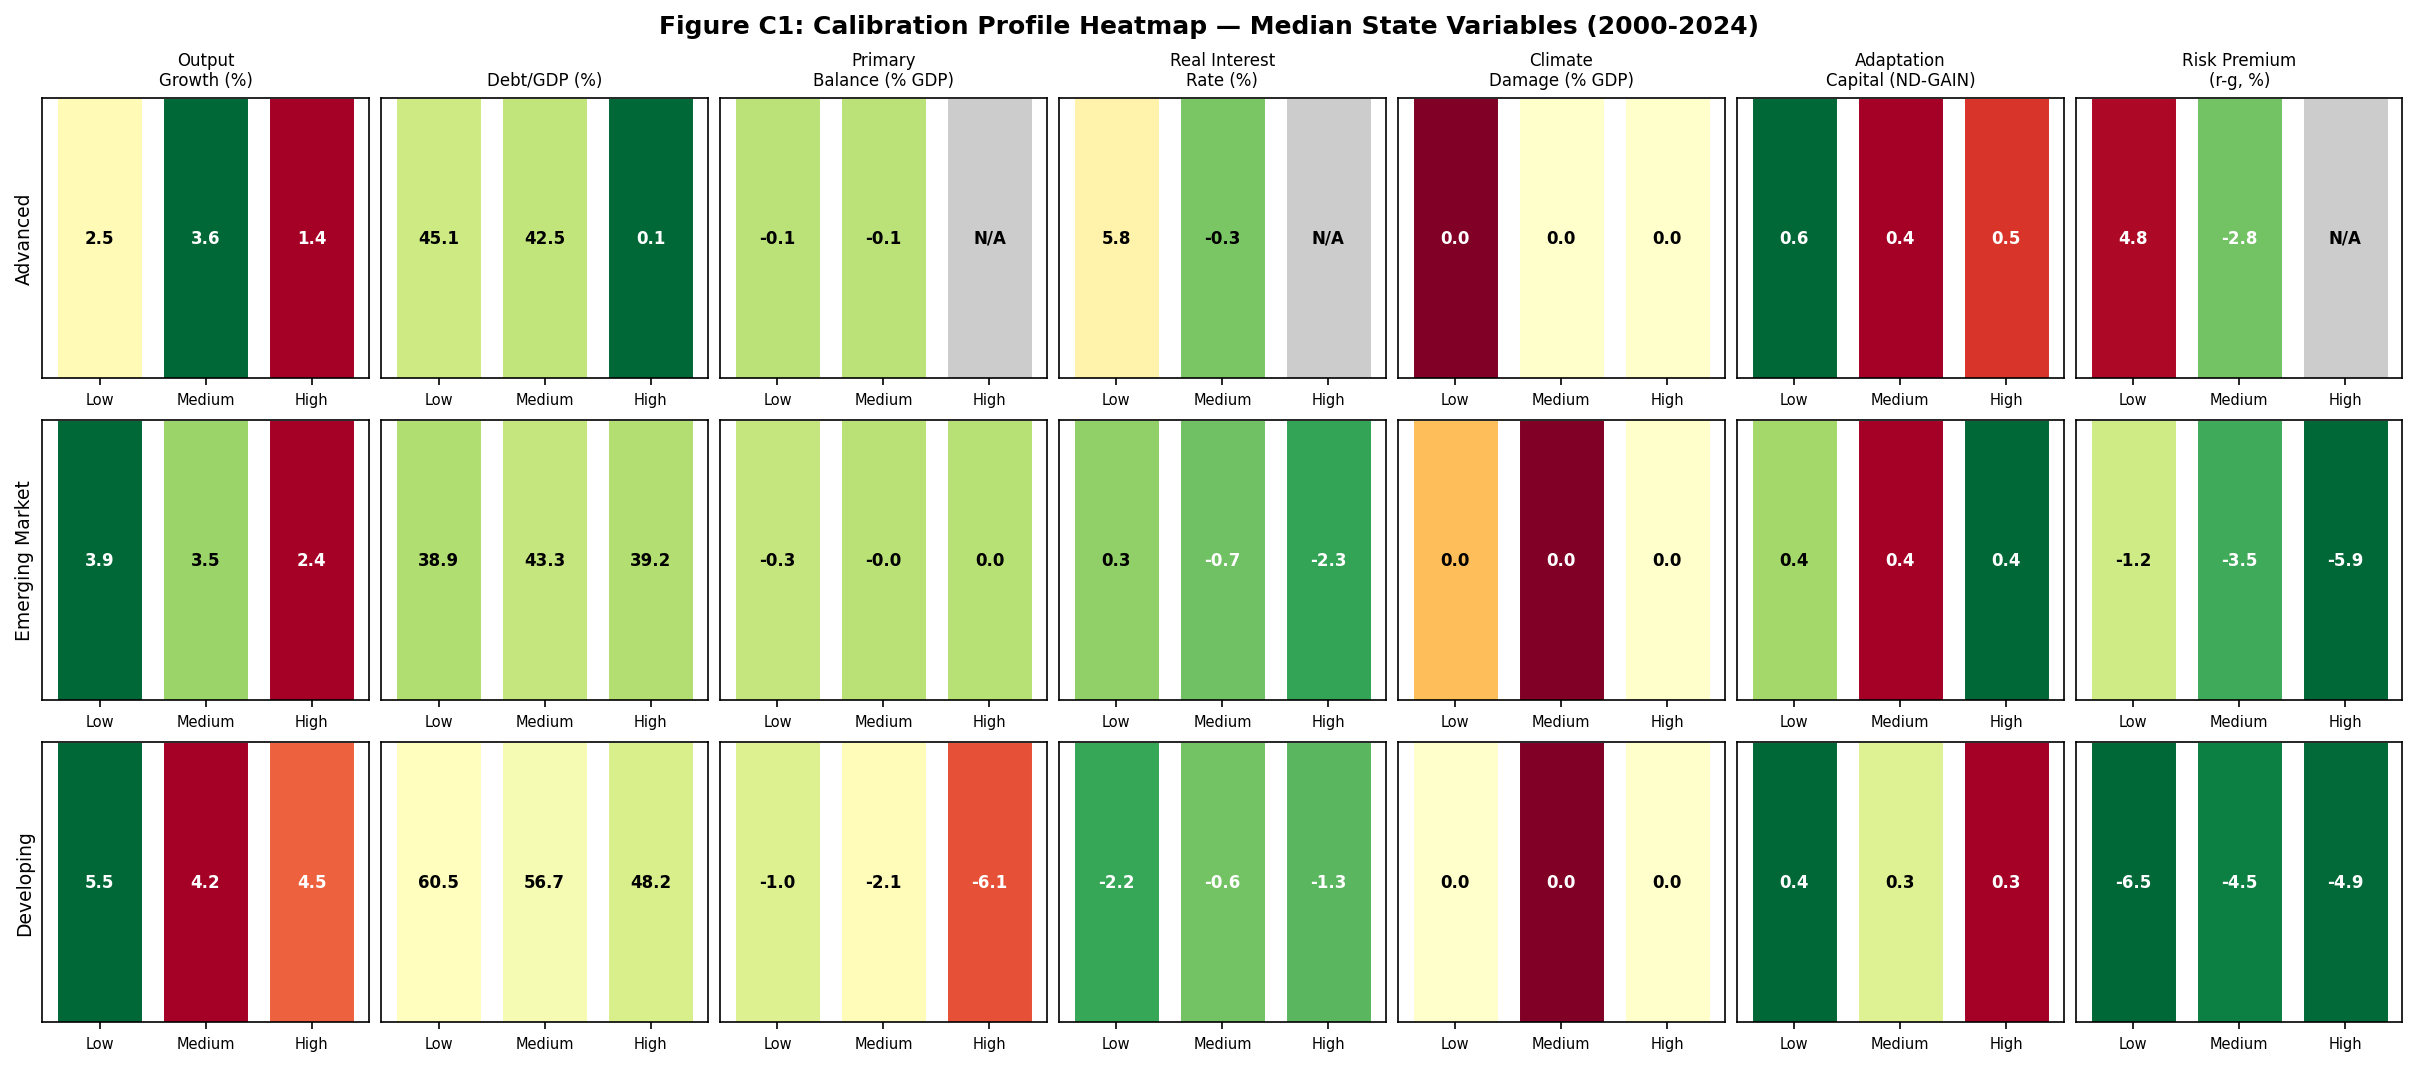

Saved: fig_C1_calibration_heatmap.png/.svg


In [25]:
# Figure C1: Calibration Profile Heatmap
sv_labels = {
    'output_growth':'Output\nGrowth (%)','debt_to_gdp':'Debt/GDP (%)',
    'primary_balance':'Primary\nBalance (% GDP)','interest_rate':'Real Interest\nRate (%)',
    'climate_shock':'Climate\nDamage (% GDP)','adaptation_capital':'Adaptation\nCapital (ND-GAIN)',
    'risk_premium':'Risk Premium\n(r-g, %)',
}
sv_cmaps = {
    'output_growth':('RdYlGn',None,None),'debt_to_gdp':('RdYlGn_r',0,120),
    'primary_balance':('RdYlGn',-8,4),'interest_rate':('RdYlGn_r',-5,15),
    'climate_shock':('YlOrRd',0,None),'adaptation_capital':('RdYlGn',None,None),
    'risk_premium':('RdYlGn_r',-5,5),
}
etypes = ['Advanced','Emerging Market','Developing']
tiers  = ['Low','Medium','High']
fig, axes = plt.subplots(3, len(sv_labels), figsize=(16,7), constrained_layout=True)
fig.suptitle('Figure C1: Calibration Profile Heatmap — Median State Variables (2000-2024)',
             fontsize=12, fontweight='bold')
for i_row,etype in enumerate(etypes):
    for i_col,(sv,label) in enumerate(sv_labels.items()):
        ax = axes[i_row,i_col]
        vals = []
        for tier in tiers:
            row = calib_v2[(calib_v2['economy_type']==etype)&(calib_v2['climate_risk_tier']==tier)]
            vals.append(row[f'{sv}_median'].values[0] if len(row)>0 else np.nan)
        cmap_name,vmin,vmax = sv_cmaps[sv]
        safe = [v for v in vals if not np.isnan(v)]
        if not safe: ax.axis('off'); continue
        _vmin = vmin if vmin is not None else min(safe)
        _vmax = vmax if vmax is not None else max(safe)
        if _vmin==_vmax: _vmax=_vmin+1
        cmap = plt.get_cmap(cmap_name)
        colors = [cmap((v-_vmin)/(_vmax-_vmin)) if not np.isnan(v) else (0.8,0.8,0.8,1) for v in vals]
        ax.bar(range(3),[1,1,1],color=colors,edgecolor='white',linewidth=0.5)
        for j,v in enumerate(vals):
            txt = f'{v:.1f}' if not np.isnan(v) else 'N/A'
            brightness = sum(colors[j][:3])/3
            ax.text(j,0.5,txt,ha='center',va='center',fontsize=8,fontweight='bold',
                    color='white' if brightness<0.55 else 'black')
        ax.set_xticks(range(3)); ax.set_xticklabels(tiers,fontsize=7)
        ax.set_yticks([]); ax.set_ylim(0,1)
        if i_row==0: ax.set_title(label,fontsize=8)
        if i_col==0: ax.set_ylabel(etype,fontsize=9,rotation=90,labelpad=4)
plt.savefig('outputs/figures/fig_C1_calibration_heatmap.png',dpi=300,bbox_inches='tight')
plt.savefig('outputs/figures/fig_C1_calibration_heatmap.svg',bbox_inches='tight')
plt.show()
print('Saved: fig_C1_calibration_heatmap.png/.svg')

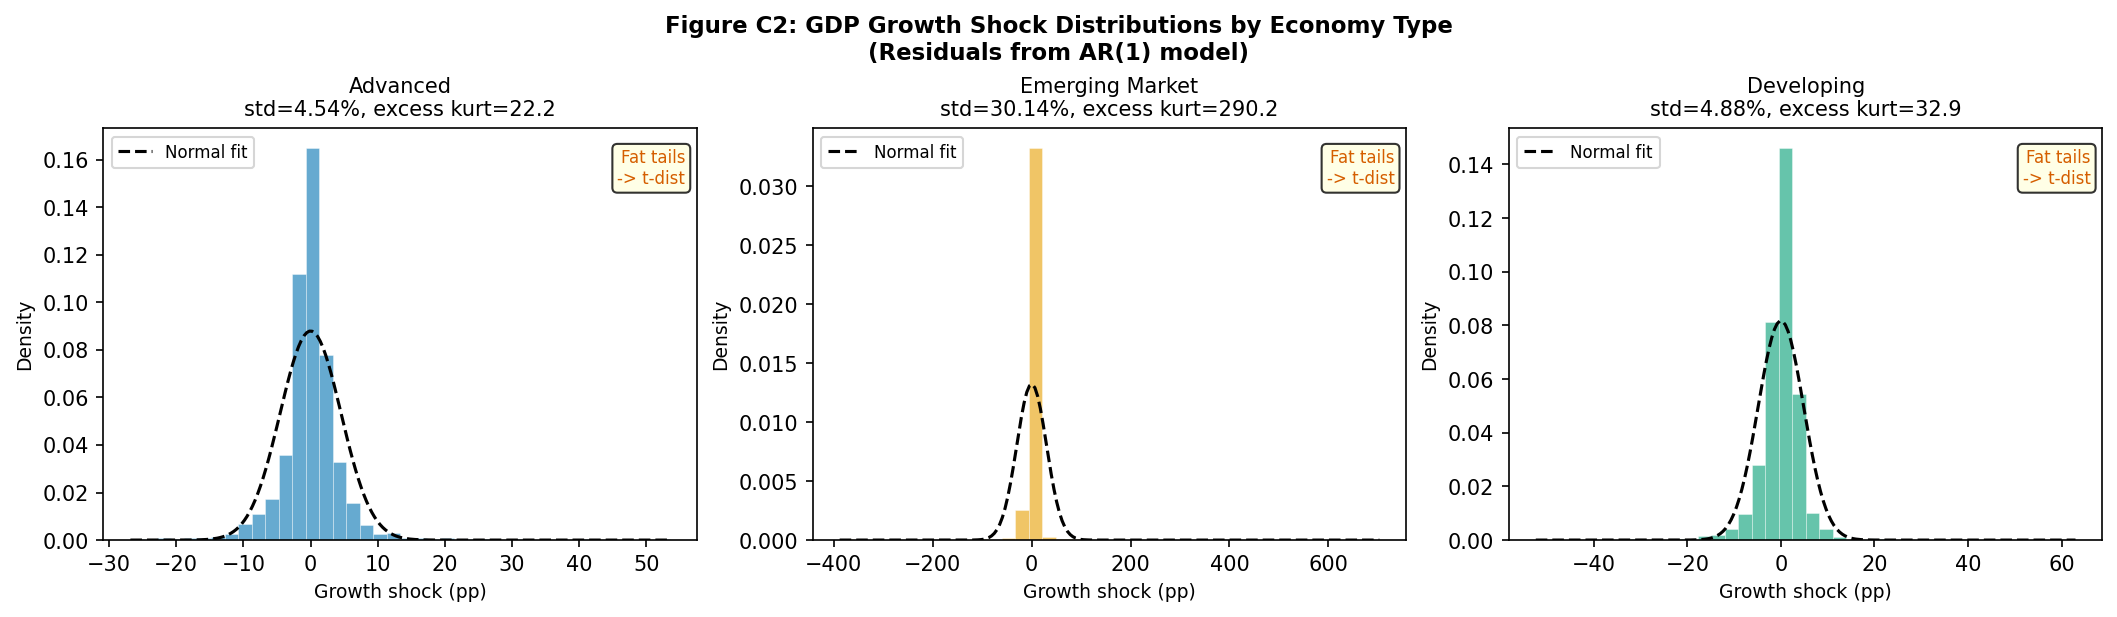

Saved: fig_C2_shock_distributions.png/.svg


In [24]:
# Figure C2: Shock Distribution Comparison
fig, axes = plt.subplots(1,3,figsize=(14,4),constrained_layout=True)
fig.suptitle('Figure C2: GDP Growth Shock Distributions by Economy Type\n(Residuals from AR(1) model)',
             fontsize=11,fontweight='bold')
for ax,etype,color in zip(axes,etypes,CB_COLORS[:3]):
    sub = calib_df[calib_df['economy_type']==etype].dropna(subset=['gdp_growth','gdp_growth_lag1'])
    try:
        X = sm.add_constant(sub[['gdp_growth_lag1']])
        resid = sm.OLS(sub['gdp_growth'],X).fit().resid.values
    except Exception:
        resid = sub['gdp_growth'].values
    kurt = stats.kurtosis(resid,fisher=True)
    mu,sigma = resid.mean(),resid.std()
    ax.hist(resid,bins=40,density=True,alpha=0.6,color=color,edgecolor='white',linewidth=0.3)
    x_r = np.linspace(resid.min(),resid.max(),200)
    ax.plot(x_r,stats.norm.pdf(x_r,mu,sigma),'k--',lw=1.5,label='Normal fit')
    ax.set_title(f'{etype}\nstd={sigma:.2f}%, excess kurt={kurt:.1f}',fontsize=10)
    ax.set_xlabel('Growth shock (pp)',fontsize=9); ax.set_ylabel('Density',fontsize=9)
    ax.legend(fontsize=8)
    if kurt>4:
        ax.text(0.98,0.95,'Fat tails\n-> t-dist',transform=ax.transAxes,ha='right',va='top',
                fontsize=8,color='#D55E00',bbox=dict(boxstyle='round,pad=0.3',facecolor='lightyellow',alpha=0.8))
plt.savefig('outputs/figures/fig_C2_shock_distributions.png',dpi=300,bbox_inches='tight')
plt.savefig('outputs/figures/fig_C2_shock_distributions.svg',bbox_inches='tight')
plt.show()
print('Saved: fig_C2_shock_distributions.png/.svg')

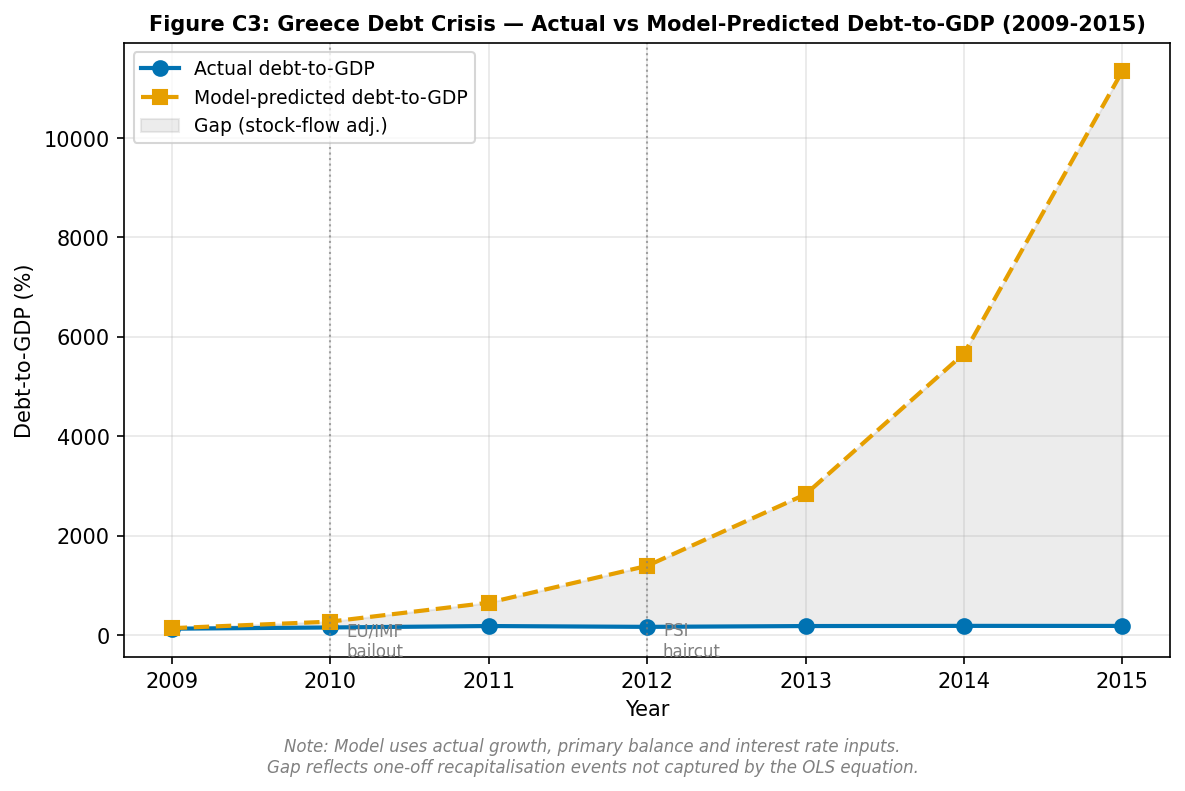

Saved: fig_C3_debt_validation_greece.png/.svg


In [25]:
# Figure C3: Greece Debt Crisis
fig, ax = plt.subplots(figsize=(8,5))
if grc_sim is not None and len(grc_sim)>0:
    ax.plot(grc_sim['year'],grc_sim['debt_actual'],'o-',color=CB_COLORS[0],lw=2,ms=7,label='Actual debt-to-GDP')
    ax.plot(grc_sim['year'],grc_sim['debt_predicted'],'s--',color=CB_COLORS[1],lw=2,ms=7,label='Model-predicted debt-to-GDP')
    ax.fill_between(grc_sim['year'],grc_sim['debt_actual'],grc_sim['debt_predicted'],
                    alpha=0.15,color='grey',label='Gap (stock-flow adj.)')
    ylim = ax.get_ylim()
    for yr,lbl in [(2010,'EU/IMF\nbailout'),(2012,'PSI\nhaircut')]:
        ax.axvline(yr,color='grey',ls=':',lw=1,alpha=0.7)
        ax.text(yr+0.1,ylim[0]+5,lbl,fontsize=8,color='grey')
else:
    ax.text(0.5,0.5,'No Greece simulation data',transform=ax.transAxes,ha='center',va='center')
ax.set_title('Figure C3: Greece Debt Crisis — Actual vs Model-Predicted Debt-to-GDP (2009-2015)',
             fontsize=10,fontweight='bold')
ax.set_xlabel('Year',fontsize=10); ax.set_ylabel('Debt-to-GDP (%)',fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3); ax.set_xticks(range(2009,2016))
fig.text(0.5,-0.04,
    'Note: Model uses actual growth, primary balance and interest rate inputs.\n'
    'Gap reflects one-off recapitalisation events not captured by the OLS equation.',
    ha='center',fontsize=8,color='grey',style='italic')
plt.tight_layout()
plt.savefig('outputs/figures/fig_C3_debt_validation_greece.png',dpi=300,bbox_inches='tight')
plt.savefig('outputs/figures/fig_C3_debt_validation_greece.svg',bbox_inches='tight')
plt.show()
print('Saved: fig_C3_debt_validation_greece.png/.svg')

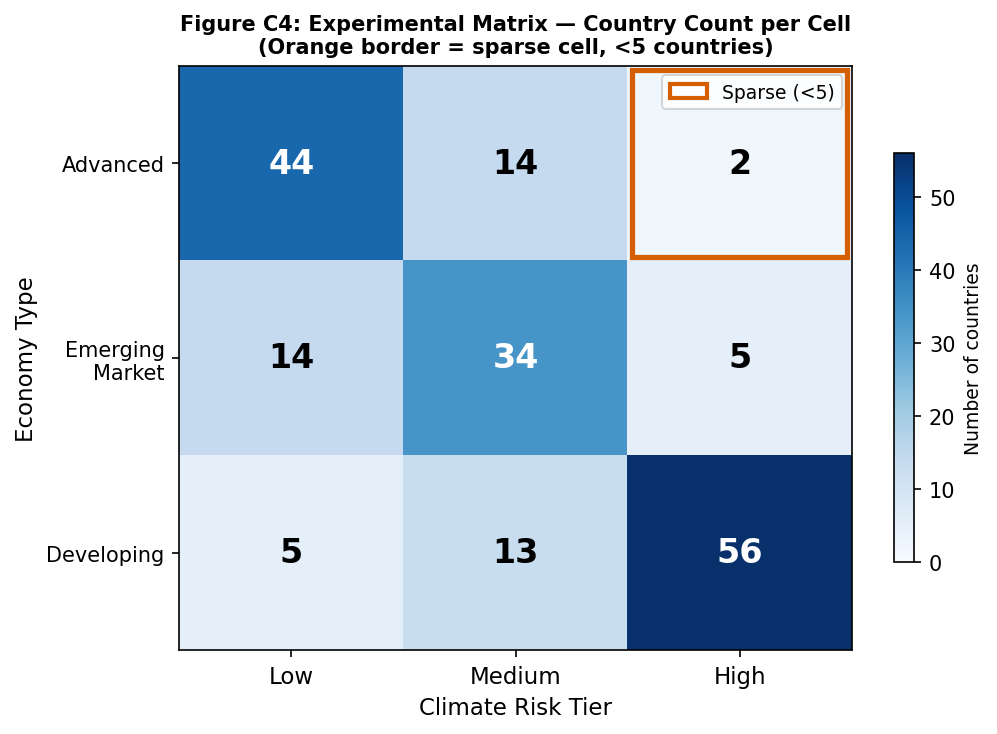

Saved: fig_C4_matrix_balance.png/.svg


: 

In [ ]:
# Figure C4: Experimental Matrix Balance
etype_order = ['Advanced','Emerging Market','Developing']
tier_order  = ['Low','Medium','High']
count_matrix = np.zeros((3,3),dtype=int)
sparse_flags = np.zeros((3,3),dtype=bool)
for i,etype in enumerate(etype_order):
    for j,tier in enumerate(tier_order):
        n = rl_meta[(rl_meta['economy_type']==etype)&(rl_meta['climate_risk_tier']==tier)].shape[0]
        count_matrix[i,j]=n; sparse_flags[i,j]=(n<5)
fig,ax = plt.subplots(figsize=(7,5))
im = ax.imshow(count_matrix,cmap='Blues',aspect='auto',vmin=0)
for i in range(3):
    for j in range(3):
        n = count_matrix[i,j]
        color = 'white' if n>count_matrix.max()*0.6 else 'black'
        ax.text(j,i,str(n),ha='center',va='center',fontsize=16,fontweight='bold',color=color)
        if sparse_flags[i,j]:
            rect = mpatches.FancyBboxPatch((j-0.48,i-0.48),0.96,0.96,
                                           boxstyle='square,pad=0',linewidth=2.5,
                                           edgecolor='#D55E00',facecolor='none')
            ax.add_patch(rect)
ax.set_xticks(range(3)); ax.set_xticklabels(['Low','Medium','High'],fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(['Advanced','Emerging\nMarket','Developing'],fontsize=10)
ax.set_xlabel('Climate Risk Tier',fontsize=11); ax.set_ylabel('Economy Type',fontsize=11)
ax.set_title('Figure C4: Experimental Matrix — Country Count per Cell\n(Orange border = sparse cell, <5 countries)',
             fontsize=10,fontweight='bold')
fig.colorbar(im,ax=ax,shrink=0.7).set_label('Number of countries',fontsize=9)
ax.legend(handles=[mpatches.Patch(edgecolor='#D55E00',facecolor='none',linewidth=2,label='Sparse (<5)')],
          loc='upper right',fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/fig_C4_matrix_balance.png',dpi=300,bbox_inches='tight')
plt.savefig('outputs/figures/fig_C4_matrix_balance.svg',bbox_inches='tight')
plt.show()
print('Saved: fig_C4_matrix_balance.png/.svg')

---
## Step 7: Save All Calibration Outputs

In [27]:
# Step 7: Save all final outputs + print final summary
print('=== STEP 7: Saving all outputs ===')

# 1. master_panel_engineered
df.to_csv('data/processed/master_panel_engineered.csv', index=False)
print(f'master_panel_engineered.csv: {df.shape}')

# 2. rl_training_data -- rebuild cleanly
state_cols = ['state_output_growth','state_debt_to_gdp','state_primary_balance',
              'state_interest_rate','state_climate_shock','state_adaptation_capital','state_risk_premium']
raw_cols   = ['gdp_growth','debt_to_gdp','weo_primary_balance',
              'real_interest_rate_winsorised','climate_damage_gdp_pct_5yr','ndgain_readiness','r_minus_g_corrected']
rl_cols = ['iso3','year','economy_type','climate_risk_tier'] + state_cols + raw_cols + ['is_projection']
rl_df = df[~df['iso3'].isin(EXCLUDE_FROM_RL)][rl_cols].copy()
rl_df.to_csv('data/processed/rl_training_data.csv', index=False)
print(f'rl_training_data.csv: {rl_df.shape} (excluded {len(EXCLUDE_FROM_RL)} territories)')

# 3. scaling_parameters
with open('data/processed/scaling_parameters.json','w') as f:
    json.dump(scaling_params, f, indent=2)
print('scaling_parameters.json: updated')

print()
print('='*65)
print('=== CALIBRATION COMPLETE ===')
print('='*65)
print(f'Corrected: inflation, real_interest_rate, r_minus_g, state_interest_rate, state_risk_premium')
print(f'Excluded territories: {EXCLUDE_FROM_RL}')
print(f'Assigned: KNA -> Low, SSD -> High')
print()
print('Updated files:')
print(f'  master_panel_engineered.csv:   {df.shape}')
print(f'  rl_training_data.csv:          {rl_df.shape}')
print(f'  scaling_parameters.json:       updated')
print(f'  calibration_profiles_v2.csv:   9 profiles')
print(f'  transition_dynamics.json:      3 equation sets')
print(f'  shock_parameters.json:         3 shock types x 9 profiles')
print(f'  calibration_validation.csv:    4 episodes')
print()
print('Experimental matrix (country counts):')
rl_meta2 = df[~df['iso3'].isin(EXCLUDE_FROM_RL)][['iso3','economy_type','climate_risk_tier']].drop_duplicates('iso3')
xt = pd.crosstab(rl_meta2['economy_type'],rl_meta2['climate_risk_tier'],margins=True,margins_name='Total')
cf = [c for c in ['Low','Medium','High','Total'] if c in xt.columns]
rf = [r for r in ['Advanced','Emerging Market','Developing','Total'] if r in xt.index]
print(xt.loc[rf,cf].to_string())
print()
print('Sparse cells flagged (<5 countries or <100 obs):')
for etype,tier,n_ctry,n_obs in sparse_cells:
    print(f'  {etype} x {tier}: {n_ctry} countries -> interpret with caution')
print()
print('Validation summary:')
for row in validation_summary:
    print(f'  {row["episode"]}: {row["result"]}')
print()
print('Figures: outputs/figures/')
for fn in ['fig_C1_calibration_heatmap','fig_C2_shock_distributions',
           'fig_C3_debt_validation_greece','fig_C4_matrix_balance']:
    print(f'  {fn}.png / .svg')
print('\nNotebook 05 complete.')

=== STEP 7: Saving all outputs ===


master_panel_engineered.csv: (7559, 88)
rl_training_data.csv: (7241, 19) (excluded 9 territories)
scaling_parameters.json: updated

=== CALIBRATION COMPLETE ===
Corrected: inflation, real_interest_rate, r_minus_g, state_interest_rate, state_risk_premium
Excluded territories: ['ABW', 'AND', 'HKG', 'MAC', 'PRI', 'SMR', 'TWN', 'UVK', 'WBG']
Assigned: KNA -> Low, SSD -> High

Updated files:
  master_panel_engineered.csv:   (7559, 88)
  rl_training_data.csv:          (7241, 19)
  scaling_parameters.json:       updated
  calibration_profiles_v2.csv:   9 profiles
  transition_dynamics.json:      3 equation sets
  shock_parameters.json:         3 shock types x 9 profiles
  calibration_validation.csv:    4 episodes

Experimental matrix (country counts):
climate_risk_tier  Low  Medium  High  Total
economy_type                               
Advanced            44      14     2     60
Emerging Market     14      34     5     53
Developing           5      13    56     74
Total               63   